# Week 5 - Expectation Maximization and Principal Component Analysis - solution

Learning contents:

1. Mixture of Gaussians: Expectation-Maximization
    - Display results
    - Nearest Centroid-based classification
2. Principal Component Analysis
    - Generate data
    - Apply PCA
    - Display projection

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import multivariate_normal, norm
from sklearn import datasets
from IPython.display import HTML

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

#### We use `iris` dataset from `sklearn`

(<matplotlib.collections.PathCollection at 0x17ff637d0>,
 <matplotlib.legend.Legend at 0x320332270>)

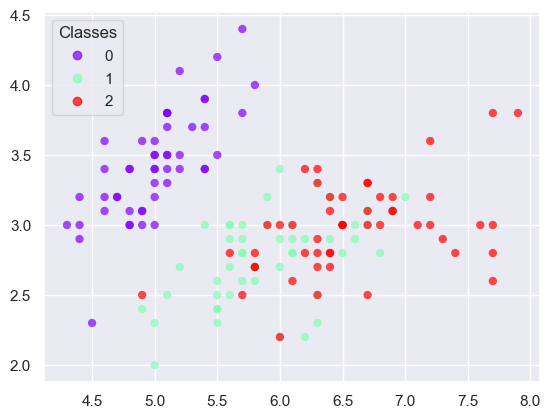

In [2]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

## 1) Mixture of Gaussians: Expectation-Maximization

`gaussian_mixture` takes data point (vector) `x`, set of multivariate `means` and respective `covariances`, and `pis` (coeficients) and should return Probability Density Function value at point x.

In [3]:
def gaussian_mixture(x, means, covariances, pis):
    result = 0
    
    for i, (mean, covariance, pi) in enumerate(zip(means, covariances, pis)):
        result += pi * multivariate_normal(mean=mean, cov=covariance, allow_singular=True).pdf(x)
    
    return result

`expectation_maximization_gaussian` takes initial means `mus_0`, covariances `covariances_0` and coeficients `pis_0`, data set `data_x` and callback `on_step`.

`on_step` is a function that takes current set of `mus`, corresponding `covariances` and `pis`, value of `log_likelihood` and list of class `predictions` for each point (\[0...k\]) and should be called each step 

In [4]:
def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x,
                                      max_iters=200, tol=1e-6, reg=1e-6):
    """
    Returns:
        steps: list of tuples per iteration:
               (mus, covariances, pis, log_likelihood, predictions)
    """
    eps = 1e-8
    N, D = data_x.shape
    K = len(mus_0)

    mus = np.array(mus_0, dtype=float)
    covs = np.array(covariances_0, dtype=float)
    pis  = np.array(pis_0, dtype=float)

    steps = []
    old_ll = None

    for it in range(max_iters):
        # ---- E-step ----
        # likelihood: (K, N)
        likelihood = np.vstack([
            multivariate_normal.pdf(
                x=data_x, mean=mus[k], cov=covs[k], allow_singular=True
            ) for k in range(K)
        ])

        weighted = likelihood * pis[:, None]          # (K, N)
        denom = weighted.sum(axis=0) + eps            # (N,)
        gamma = weighted / denom                      # (K, N)
        Nk = gamma.sum(axis=1) + eps                  # (K,)
        log_likelihood = float(np.sum(np.log(denom))) # scalar

        # hard labels (from posteriors)
        predictions = np.argmax(gamma, axis=0)

        # ---- M-step ----
        mus = (gamma @ data_x) / Nk[:, None]          # (K, D)

        new_covs = []
        for k in range(K):
            Xc = data_x - mus[k]                      # (N, D)
            W = gamma[k][:, None]                     # (N, 1)
            Sk = (Xc.T @ (W * Xc)) / Nk[k]            # (D, D)
            Sk += reg * np.eye(D)                     # regularize
            new_covs.append(Sk)
        covs = np.array(new_covs, dtype=float)

        pis = Nk / N                                  # (K,)

        # ---- record step for animation ----
        steps.append((mus.copy(), covs.copy(), pis.copy(),
                      log_likelihood, predictions.copy()))

        # ---- stopping ----
        if (old_ll is not None) and (log_likelihood - old_ll < tol):
            break
        old_ll = log_likelihood

    return steps


### 1.1) Display results

In [5]:
def plot_gaussian_mixtures(mus, covariances, pis, data, classes, cmap='rainbow', target=plt):
    
    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    
    probabilities = list(map(
        lambda x: gaussian_mixture(x, mus, covariances, pis),
        pos
    ))
    
    target.contour(x, y, probabilities, cmap=cmap)
    
    plot = plot_iris(classes=classes, target=target)
    # scatter = target.scatter(mus[:, 0], mus[:, 1], c=[0, 1, 2], cmap='rainbow', marker='data', s=300, edgecolors='black')
    return (*plot, )


def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

In [6]:
np.random.seed(26)

classes = 3

all_steps_em = []

mus_0 = iris_x[:classes]
covariances_0 = np.array([np.cov(iris_x.T)] * classes)
pis_0 = np.array([1/classes] * classes)

#expectation_maximization_gaussian(
#    mus_0, covariances_0, pis_0, iris_x,
#    lambda mus, covs, pis, log_likelihood, predictions: all_steps_em.append((mus, covs, pis, log_likelihood, predictions))
#)

all_steps_em = expectation_maximization_gaussian(
    mus_0, covariances_0, pis_0, iris_x, max_iters=100
)
# Now your animation can loop over all_steps_em without any callback.

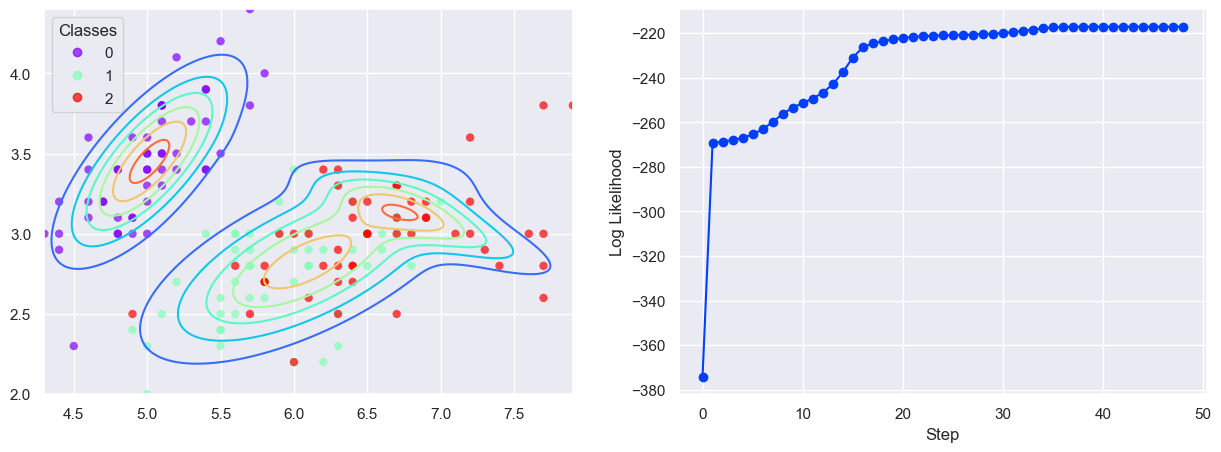

In [7]:
def create_animation(all_steps_em, data_x,iris_t):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, iris_t, target=ax)
                
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x,iris_t)

### 1.2) Nearest Centroid-based classification

`nearest_centroid_based_class` takes data point `x`, set of means `mus` and `covariances` and returns class of this point

In [8]:
def nearest_centroid_based_class(x, mus, covariances):

    distances = list(map(
        lambda mu_cov: (x - mu_cov[0]).T @ np.linalg.inv(mu_cov[1]) @ (x - mu_cov[0]),
        zip(mus, covariances)
    ))
    return np.argmin(distances)


/var/folders/w8/4ydrws9n16d44w_rm7l3kbtx_94klw/T/ipykernel_87660/744847111.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
/var/folders/w8/4ydrws9n16d44w_rm7l3kbtx_94klw/T/ipykernel_87660/744847111.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


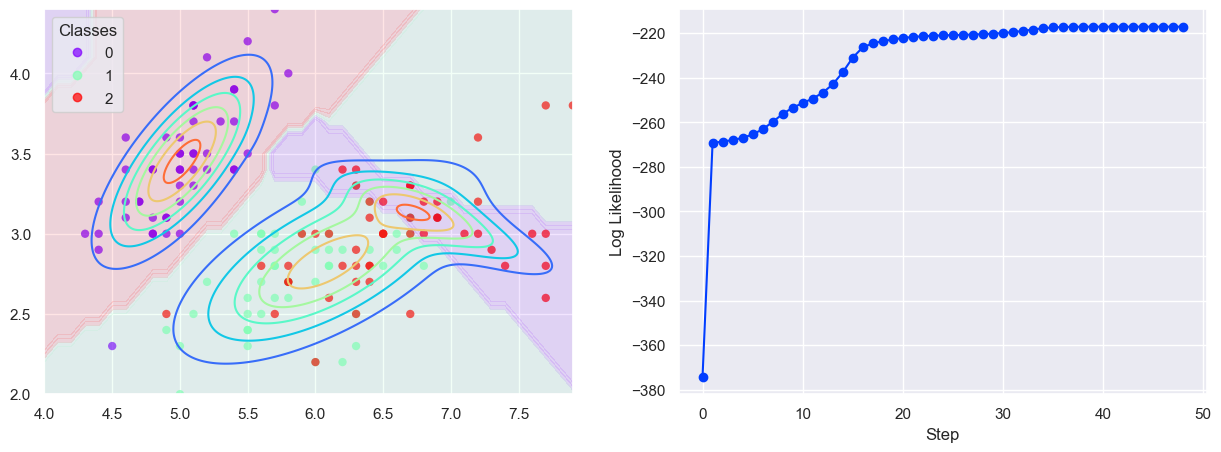

In [9]:
def create_animation(all_steps_em, data_x, iris_t):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, iris_t, target=ax)
        
        plot_mesh(
            lambda x: nearest_centroid_based_class(x, all_steps_em[i][0], all_steps_em[i][1]),
            n_class=len(all_steps_em[i][0]), target=ax
        )
        
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x, iris_t)

## 2) Principal Component Analysis

### 2.1) Generate data

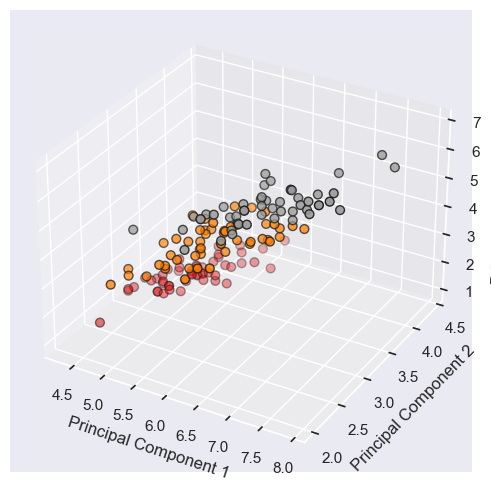

In [10]:
iris4_x = np.array(iris.data[:, :4])
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_classes_3d(data, classes):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')  # Use add_subplot with '3d' projection
    
    # Scatter plot in 3D
    scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], 
                         c=classes, cmap=plt.cm.Set1, edgecolor='k', s=40)
    
    # Add labels to the axes
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    
    plt.show()
# Call the function to plot the data
plot_classes_3d(iris4_x[:, :3], iris_t)

### 2.2) Apply PCA

`pca_projection` takes data points `data`, number of `components` as arguments and returns PCA projection of the data

In [11]:
#def pca_projection(data, components):
    
#    mean = np.mean(data, axis=0)
#    centered_data = data - mean
    
#    cov = np.cov(centered_data, rowvar=False)
#    values, vectors = np.linalg.eigh(cov)
    
#    total = [*zip(values, vectors.T)]
#    total.sort(reverse=True)

#    U = np.array([vec for (val, vec) in total[:components]])
    
#    return data @ U.T

def pca_projection(data, components):
    # Step 1: Center the data by subtracting the mean
    mean = np.mean(data, axis=0)
    centered_data = data - mean
    
    # Step 2: Calculate the covariance matrix
    cov_matrix = np.cov(centered_data, rowvar=False)
    
    # Step 3: Perform eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Step 4: Sort eigenvectors by eigenvalues (in descending order)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    top_vectors = eigenvectors[:, sorted_indices[:components]]
    
    # Step 5: Project the centered data onto the top principal components
    return centered_data @ top_vectors

### 2.3) Display projection

(<matplotlib.collections.PathCollection at 0x3205b1310>,
 <matplotlib.legend.Legend at 0x320598a70>)

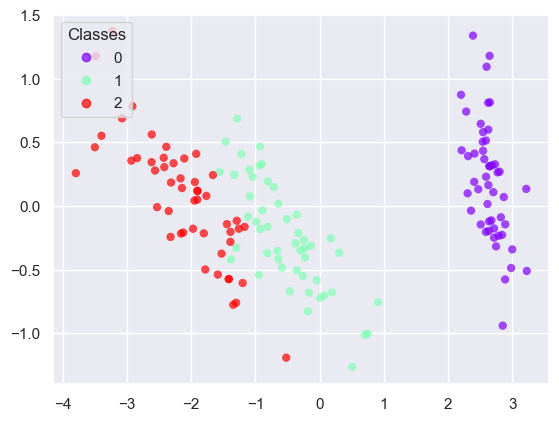

In [12]:
def plot_classes(data, classes, legend=True, target=plt):
    scatter = target.scatter(data[:, 0], data[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

projected_data = pca_projection(iris4_x, 2)
plot_classes(projected_data, iris_t)

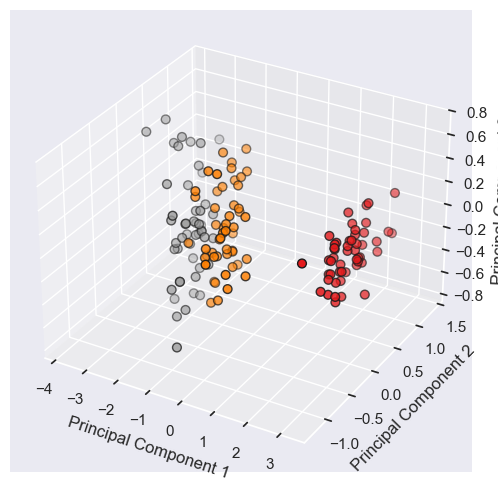

In [13]:
projected_data = pca_projection(iris4_x, 3)
plot_classes_3d(projected_data, iris_t)